In [1]:
import os
import json
import torch
import pandas as pd
import logging
import importlib
from pathlib import Path
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage
from IPython.display import Image

import sys
PROJECT_DIR = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER"
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import multiomic_transformer.utils.data_formatter as data_formatter
import multiomic_transformer.utils.experiment_handler as experiment_handler

random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

GROUND_TRUTH_DIR = Path(PROJECT_DIR) / "data" / "ground_truth_files"
DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/PROCESSED_DATA")

In [2]:
from cycler import cycler
color_palette = {
  "blue_light": "#18A6ED",
  "orange_light": "#EEA700",
  "red_light": "#EF767A",
  "green_light": "#7EE3BA",
  "purple_light": "#C798CC",
  "grey_light": "#BCBCBF",
  "blue_dark": "#2E70B9",
  "orange_dark": "#D18A3D",
  "red_dark": "#BC3E1A",
  "green_dark": "#32936F",
  "purple_dark": "#9D5ED4",
  "grey_dark": "#434B4E",
}

plt.rcParams.update({

    # figure
    "figure.figsize": (6,4),
    "figure.dpi": 300,

    # fonts
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # axes
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": False,
    "grid.alpha": 0.25,

    # lines
    "lines.linewidth": 2,

    # legend
    "legend.frameon": False,

    # color cycle
    "axes.prop_cycle": cycler(color=color_palette.values()),
})

method_color_dict = {
  "Gradient Attribution": "#4195DF",
  "LINGER": "#7EE3BA",
  "SCENIC+": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "TRIPOD": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

light_colors = [v for k,v in color_palette.items() if "light" in k]

order = ["Gradient Attribution", "LINGER", "SCENIC+", "CellOracle", "GRaNIE", "Pando", "TRIPOD", "FigR"]

In [3]:
def load_ground_truth(ground_truth_file: str|Path):
    if type(ground_truth_file) == str:
        ground_truth_file = Path(ground_truth_file)
        
    if ground_truth_file.suffix == ".csv":
        sep = ","
    elif ground_truth_file.suffix == ".tsv":
        sep="\t"
        
    ground_truth_df = pd.read_csv(ground_truth_file, sep=sep, on_bad_lines="skip", engine="python")
    
    if "chip" in ground_truth_file.name and "atlas" in ground_truth_file.name:
        ground_truth_df = ground_truth_df[["source_id", "target_id"]]

    if ground_truth_df.columns[0] != "Source" or ground_truth_df.columns[1] != "Target":
        ground_truth_df = ground_truth_df.rename(columns={ground_truth_df.columns[0]: "Source", ground_truth_df.columns[1]: "Target"})
    ground_truth_df["Source"] = ground_truth_df["Source"].astype(str).str.upper()
    ground_truth_df["Target"] = ground_truth_df["Target"].astype(str).str.upper()
    
    # Build TF, TG, and edge sets for quick lookup later
    gt = ground_truth_df[["Source", "Target"]].dropna()

    gt_tfs = set(gt["Source"].unique())
    gt_tgs = set(gt["Target"].unique())
    
    gt_pairs = (gt["Source"] + "\t" + gt["Target"]).drop_duplicates()
    
    gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))
        
    return ground_truth_df, gt_lookup

gt_by_dataset_dict = {
    "Macrophage": {
        # "RN204": load_ground_truth(GROUND_TRUTH_DIR / "rn204_macrophage_human_chipseq.tsv"),
        "ChIP-Atlas macrophage": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv"),
        "Perturb-seq macrophage": load_ground_truth(GROUND_TRUTH_DIR / "macrophage_perturbations.csv"),
    },
    "mESC": {
        "ChIP-Atlas mESC": load_ground_truth(GROUND_TRUTH_DIR / "chip_atlas_tf_peak_tg_dist.csv"),
        "RN111": load_ground_truth(GROUND_TRUTH_DIR / "RN111.tsv"),
        "RN112": load_ground_truth(GROUND_TRUTH_DIR / "RN112.tsv"),
        "RN114": load_ground_truth(GROUND_TRUTH_DIR / "RN114.tsv"),
        "RN116": load_ground_truth(GROUND_TRUTH_DIR / "RN116.tsv"),        
    },
    "K562": {
        "ChIP-Atlas K562": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_K562.csv"),
        "RN117": load_ground_truth(GROUND_TRUTH_DIR / "RN117.tsv"),        
    },
    "iPSC": {
        # "ChIP-Atlas iPSC": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC.csv"),
        "ChIP-Atlas iPSC (1 Mb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_1mb.csv"),
        # "ChIP-Atlas iPSC (100 kb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_100kb.csv"),
    }
}

In [4]:
from joblib import Parallel, delayed
from pathlib import Path
import logging
import pandas as pd
import multiomic_transformer.utils.auroc_refactored as auroc_utils

selected_preprocessing_experiments = [
    ("E7.5_rep1", "mESC_E7.5_rep1_full_pipeline", "mESC", 2),
    ("E7.5_rep2", "mESC_E7.5_rep2_full_pipeline", "mESC", 2),
    ("E8.5_rep1", "mESC_E8.5_rep1_full_pipeline", "mESC", 2),
    ("E8.5_rep2", "mESC_E8.5_rep2_full_pipeline", "mESC", 2),
    ("buffer_1", "Macrophage_buffer_1_full_pipeline", "Macrophage", 2),
    ("buffer_2", "Macrophage_buffer_2_full_pipeline", "Macrophage", 2),
    ("sample_1", "K562_sample_1_full_pipeline", "K562", 2),
    ("WT_D13_rep1", "iPSC_WT_D13_rep1_full_pipeline", "iPSC", 2),
]


def evaluate_single_method_setwise(
    method_name: str,
    score_df: pd.DataFrame,
    ground_truth: tuple[pd.DataFrame, tuple[set[str], set[str], set[str]]],
    ground_truth_name: str,
    max_edges: int = 10000,
    agg_by_tf: bool = False,
) -> pd.DataFrame | None:
    _, gt_lookup = ground_truth
    gt_tfs, gt_targets, gt_pairs = gt_lookup

    if score_df is None or score_df.empty:
        return None

    if "source_upper" in score_df.columns and "target_upper" in score_df.columns:
        df = score_df
    else:
        df = score_df[["Source", "Target"] + (["Score"] if "Score" in score_df.columns else [])].copy()
        df["source_upper"] = df["Source"].astype(str).str.upper()
        df["target_upper"] = df["Target"].astype(str).str.upper()

    mask = df["source_upper"].isin(gt_tfs) & df["target_upper"].isin(gt_targets)
    df_filtered = df.loc[mask]

    if df_filtered.empty:
        return None
    
    if agg_by_tf:
        df_final = (
            df_filtered
            .sort_values(["source_upper", "Score"], ascending=[True, False])
            .groupby("source_upper", group_keys=False)
            .head(100)
        )
    else:
        df_final = df_filtered.nlargest(max_edges, columns="Score", keep="first")

    inferred_pairs = set(df_final["source_upper"] + "\t" + df_final["target_upper"])

    tp_n = len(inferred_pairs & gt_pairs)
    fp_n = len(inferred_pairs - gt_pairs)
    fn_n = len(gt_pairs - inferred_pairs)

    precision = tp_n / (tp_n + fp_n) if (tp_n + fp_n) else 0.0
    recall = tp_n / (tp_n + fn_n) if (tp_n + fn_n) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    inferred_tfs = set(df_final["source_upper"].unique())
    inferred_targets = set(df_final["target_upper"].unique())

    return pd.DataFrame([{
        "Method": method_name,
        "GT_name": ground_truth_name,
        "GT_total_edges": len(gt_pairs),
        "GT_TFs": len(gt_tfs),
        "GT_targets": len(gt_targets),
        "Original_network_size": len(score_df),
        "Filtered_network_size": len(df_filtered),
        "Final_network_size": len(inferred_pairs),
        "Inferred_TFs": len(inferred_tfs),
        "Inferred_targets": len(inferred_targets),
        "TP": tp_n,
        "FP": fp_n,
        "FN": fn_n,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1_score": round(f1, 4),
        "Common_TFs": len(gt_tfs & inferred_tfs),
        "Common_targets": len(gt_targets & inferred_targets),
    }])


def evaluate_one_sample(args):
    sample_name, experiment_name, sample_type, model_num = args

    experiment_dir = (
        Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/EXPERIMENTS/")
        / experiment_name
        / f"model_training_{model_num:03d}"
    )

    standardized_method_dict = auroc_utils.load_other_method_muon_grns([sample_name], sample_type)
    if not Path(experiment_dir / "inferred_grn.csv").exists():
        logging.warning(f"{experiment_name} does not have an inferred_grn.csv. Skipping Gradient Attribution for this sample.")
        return None
    
    grn_df = pd.read_csv(experiment_dir / "inferred_grn.csv", index_col=None)
    standardized_method_dict["Gradient Attribution"] = grn_df

    sample_results = []

    for gt_name, ground_truth in gt_by_dataset_dict[sample_type].items():
        for method_name, method_grn_df in standardized_method_dict.items():
            result = evaluate_single_method_setwise(
                method_name=method_name,
                score_df=method_grn_df,
                ground_truth=ground_truth,
                ground_truth_name=gt_name,
                max_edges=10000,
            )

            if result is not None:
                result["sample_name"] = sample_name
                result["sample_type"] = sample_type
                sample_results.append(result)

    if sample_results:
        return pd.concat(sample_results, ignore_index=True)

    return None

result_dfs = []

max_workers = 4

result_dfs = Parallel(n_jobs=4)(
    delayed(evaluate_one_sample)(exp)
    for exp in selected_preprocessing_experiments
)

result_dfs = [df for df in result_dfs if df is not None]
combined_df = pd.concat(result_dfs, ignore_index=True)
print(combined_df.head())


Processing sample: E7.5_rep1 | Dataset: mESC
  - Loading SCENIC+
  - Loading LINGER
  - Loading CellOracle

Processing sample: E7.5_rep2 | Dataset: mESC
  - Loading SCENIC+
  - Loading LINGER
  - Loading CellOracle

Processing sample: E8.5_rep1 | Dataset: mESC
  - Loading SCENIC+
  - Loading LINGER
  - Loading CellOracle

Processing sample: E8.5_rep2 | Dataset: mESC
  - Loading SCENIC+
  - Loading LINGER
  - Loading CellOracle

Processing sample: buffer_1 | Dataset: Macrophage
  - Loading SCENIC+
  - Loading LINGER
  - Loading CellOracle

Processing sample: buffer_2 | Dataset: Macrophage
  - Loading SCENIC+
  - Loading LINGER
  - Loading CellOracle

Processing sample: sample_1 | Dataset: K562
  - Loading SCENIC+
  - Loading LINGER
  - Loading CellOracle

Processing sample: WT_D13_rep1 | Dataset: iPSC
  - Loading SCENIC+
  - Loading LINGER
  - Loading CellOracle


                 Method          GT_name  GT_total_edges  GT_TFs  GT_targets  \
0               SCENIC+  ChIP-Atlas mESC          771359     131       24821   
1                LINGER  ChIP-Atlas mESC          771359     131       24821   
2            CellOracle  ChIP-Atlas mESC          771359     131       24821   
3  Gradient Attribution  ChIP-Atlas mESC          771359     131       24821   
4               SCENIC+            RN111          972636     247       25692   

   Original_network_size  Filtered_network_size  Final_network_size  \
0                  12394                   4238                4238   
1               12930088                1366621               10000   
2                1298213                 186366               10000   
3               17964647                1186319               10000   
4                  12394                   1395                1395   

   Inferred_TFs  Inferred_targets    TP    FP      FN  Precision  Recall  \
0            17 

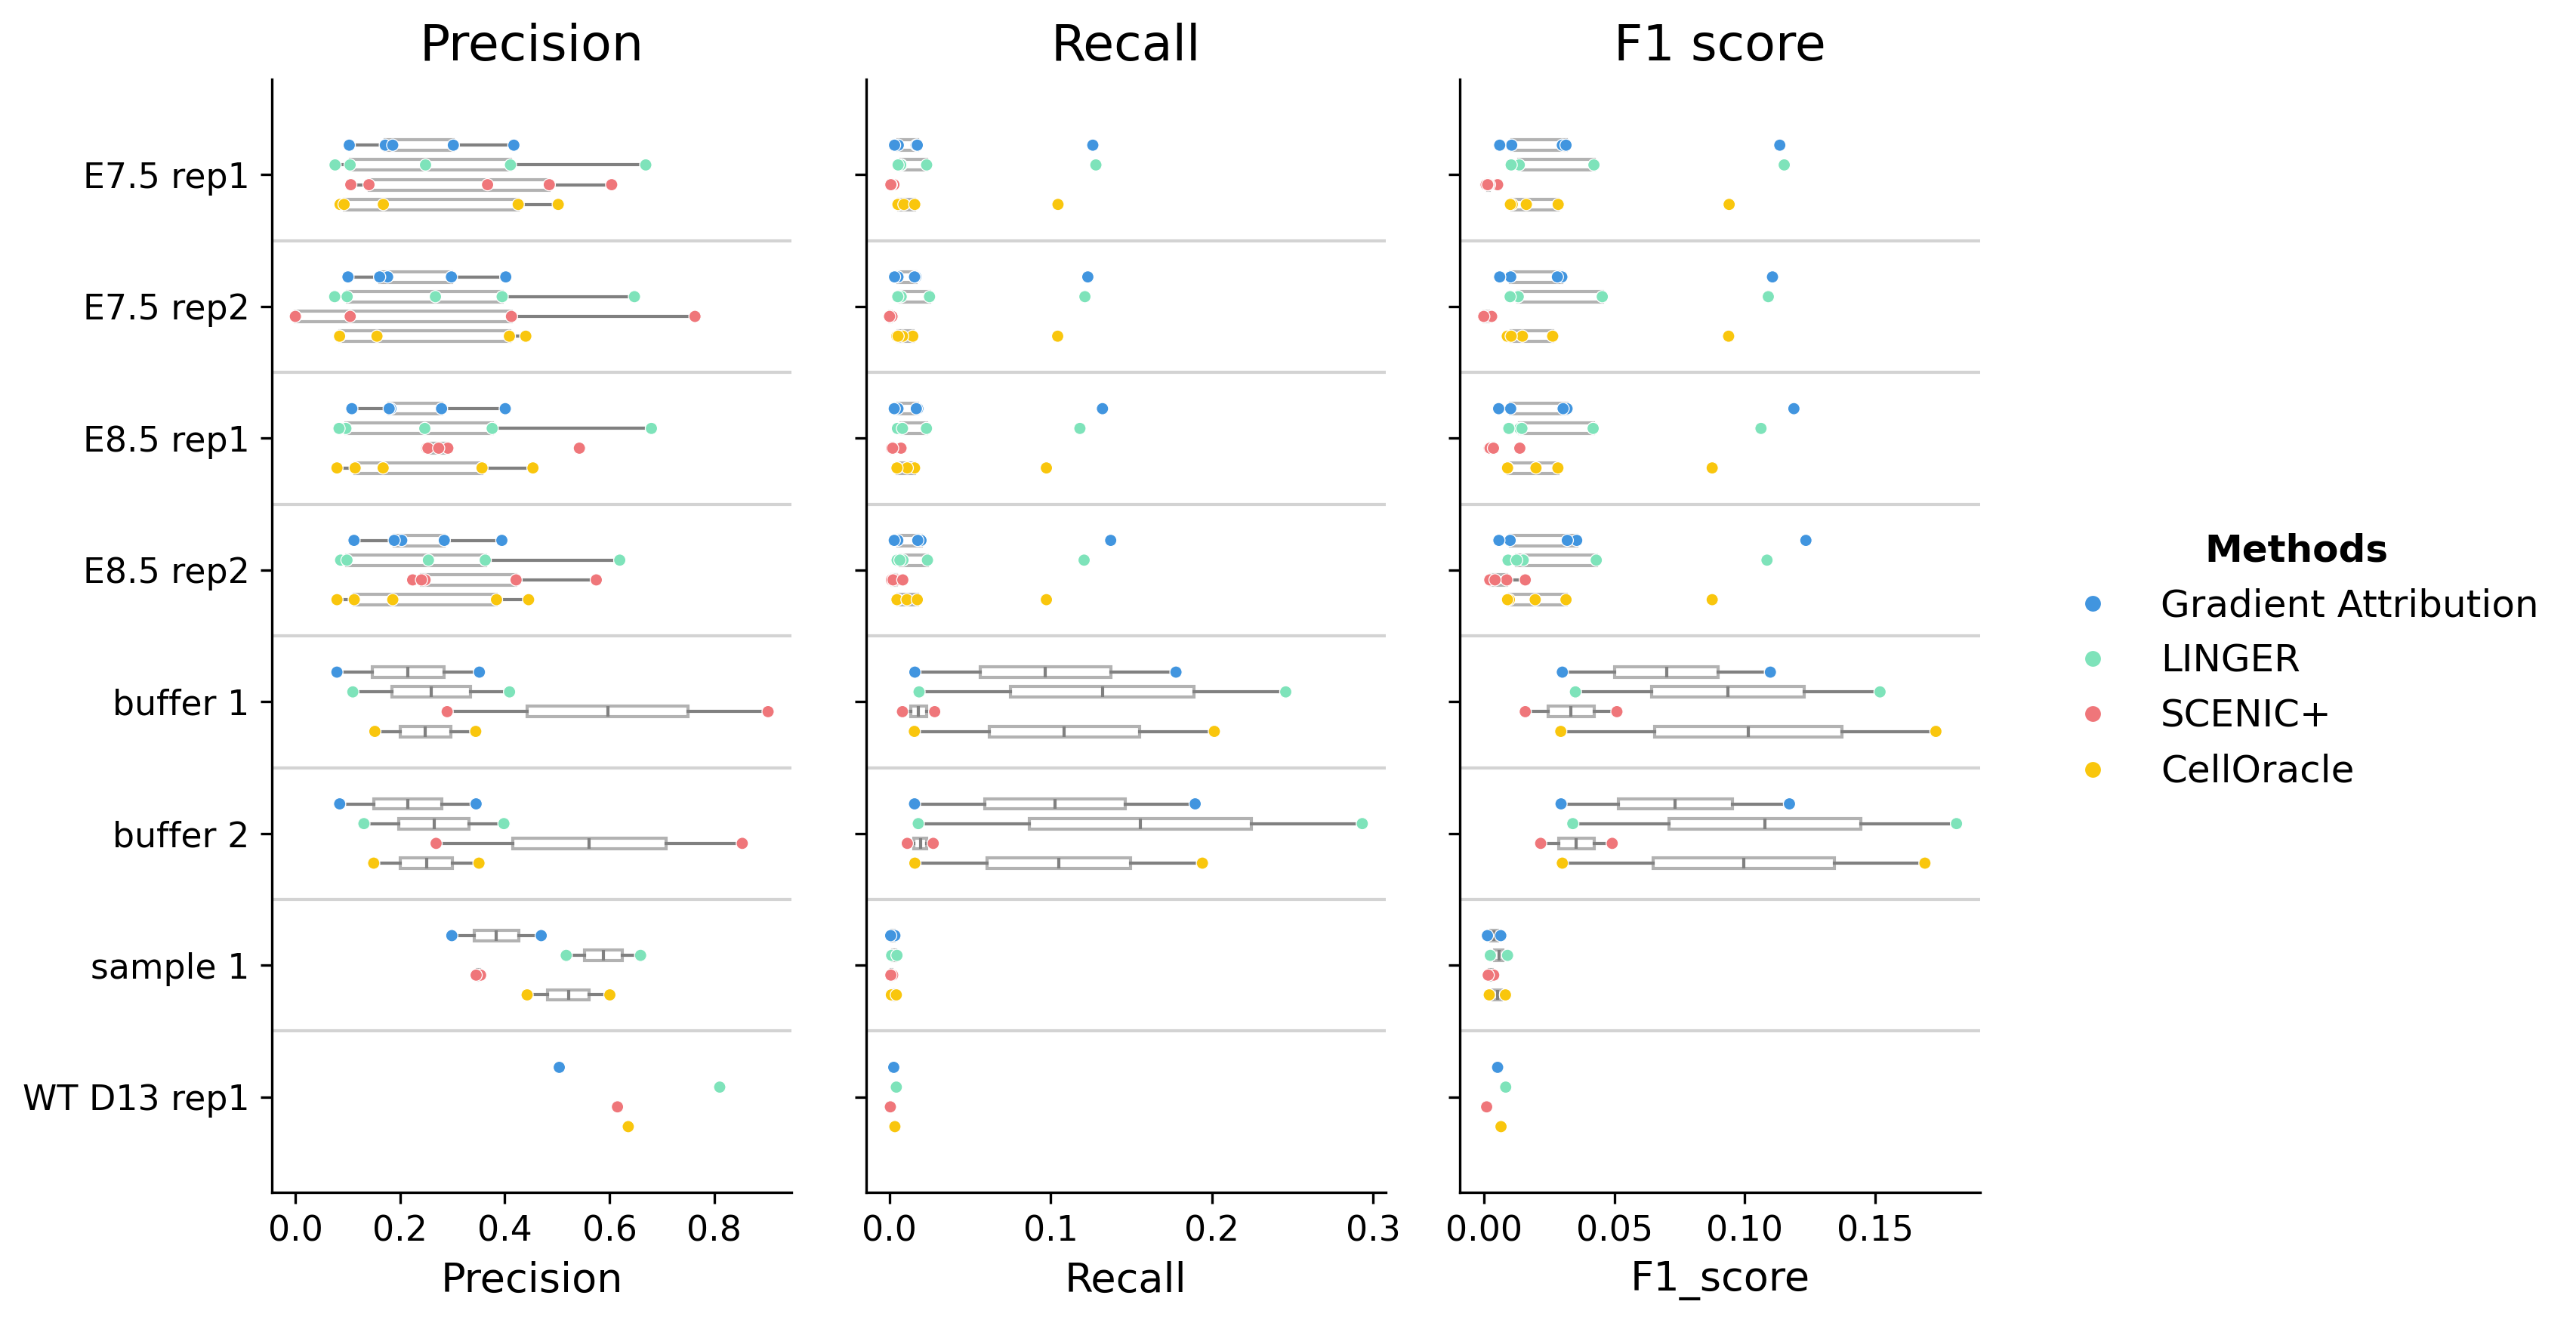

In [26]:
from matplotlib.lines import Line2D

plot_df = combined_df.copy()

# Keep only methods that are actually present, in your desired order
methods_in_plot = plot_df["Method"].unique().tolist()
method_order = [m for m in method_color_dict.keys() if m in methods_in_plot]

# Make sample order explicit and stable
sample_order = plot_df["sample_name"].drop_duplicates().tolist()

# Map sample names to base y positions
sample_to_y = {sample: i for i, sample in enumerate(sample_order)}
plot_df["y_base"] = plot_df["sample_name"].map(sample_to_y)

# Create fixed offsets for each method
offset_width = 0.15
n_methods = len(method_order)
offsets = np.linspace(
    -offset_width * (n_methods - 1) / 2,
    offset_width * (n_methods - 1) / 2,
    n_methods
)
method_to_offset = dict(zip(method_order, offsets))

plot_df["y_offset"] = plot_df["Method"].map(method_to_offset)
plot_df["y_position"] = plot_df["y_base"] + plot_df["y_offset"]

# Control draw order so earlier methods are plotted last / on top
plot_df["Method"] = pd.Categorical(plot_df["Method"], categories=method_order, ordered=True)
plot_df = plot_df.sort_values("Method", ascending=False)

metrics = ["Precision", "Recall", "F1_score"]

fig, axes = plt.subplots(
    ncols=len(metrics),
    nrows=1,
    figsize=(9, 6),
    sharey=True
)

# Clean y tick labels
y_ticks = list(sample_to_y.values())
y_tick_labels = [s.replace("_", " ") for s in sample_to_y.keys()]

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    # Group data for boxplots
    grouped = (
        plot_df
        .groupby(["sample_name", "Method"])
    )
    
    colors = [method_color_dict[m] for (_, m) in grouped.groups.keys()]

    box_data = []
    box_positions = []
    box_colors = []

    for sample in sample_order:
        for method in method_order:
            group = plot_df[
                (plot_df["sample_name"] == sample) &
                (plot_df["Method"] == method)
            ]

            if group.empty:
                continue

            y_base = sample_to_y[sample]
            offset = method_to_offset[method]
            y_pos = y_base + offset

            box_data.append(group[metric].values)
            box_positions.append(y_pos)
            box_colors.append(method_color_dict[method])

    bp = ax.boxplot(
        box_data,
        positions=box_positions,
        vert=False,
        widths=0.08,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="white", alpha=0.3, linewidth=1),
        whiskerprops=dict(color="gray", linewidth=1),
        capprops=dict(color="gray", linewidth=1),
        medianprops=dict(color="gray", linewidth=1),
        zorder=1
    )

    # for patch, color in zip(bp["boxes"], box_colors):
    #     patch.set_facecolor(color)
    #     patch.set_alpha(0.7)
        
    sns.scatterplot(
        data=plot_df,
        x=metric,
        y="y_position",
        hue="Method",
        hue_order=method_order,
        palette=method_color_dict,
        s=15,
        ax=ax,
        legend=False,
        zorder=2
    )

    # Horizontal separator lines between samples
    for y in range(len(sample_to_y) - 1):
        ax.axhline(y=y + 0.5, color="lightgray", linewidth=1, zorder=0)

    ax.set_title(metric.replace("_", " "))
    ax.grid(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    
    ax.invert_yaxis()

    # Set y-axis ticks/labels
    if i == 0:
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_tick_labels)
        ax.set_ylabel("")
    else:
        ax.set_yticks(y_ticks)   # keep alignment
        ax.set_yticklabels([])
        ax.set_ylabel("")

handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=method_color_dict[m],
        markersize=6,
        label=m
    )
    for m in method_order
]

fig.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.00, 0.5),
    title="Methods",
    title_fontproperties={'weight': 'bold'}
)

axes[0].set_yticks(y_ticks)
axes[0].set_yticklabels(y_tick_labels)

fig.tight_layout()
plt.show()